# Exploración inicial — NYC Yellow Taxi (enero 2025)

**Objetivo del proyecto:** predecir la duración de un viaje en minutos usando solo información disponible al momento del recojo.

Este notebook cubre lo siguiente: carga de datos, dimensiones y tipos, valores faltantes, distribución de la variable objetivo, ≥5 visualizaciones, outliers, discusión de leakage/sesgos y un primer baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Carga de datos

Descargamos un mes completo (enero 2025) directamente de la TLC en formato Parquet. Si el archivo ya existe en `../data/`, se usa la copia local.

In [2]:
import os, ssl, urllib.request

URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet"
LOCAL = "../data/yellow_tripdata_2025-01.parquet"

if not os.path.exists(LOCAL):
    print("Descargando...")
    try:
        urllib.request.urlretrieve(URL, LOCAL)
    except urllib.error.URLError:
        # Algunas instalaciones de Python en macOS no traen certificados raíz; usamos los de certifi
        import certifi
        ctx = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(URL, context=ctx) as r, open(LOCAL, "wb") as f:
            f.write(r.read())

df = pd.read_parquet(LOCAL)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Descargando...
Filas: 3,475,226 | Columnas: 20


## 2. Estructura: tipos de datos y primeras filas

In [3]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


## 3. Valores faltantes por variable

In [5]:
faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes_df = faltantes[faltantes > 0].round(2).to_frame("% faltante")
print(faltantes_df if len(faltantes_df) else "Sin NaN explícitos — pero ojo: hay faltantes encubiertos (passenger_count=0, zonas 264/265).")
faltantes_df

                      % faltante
passenger_count            15.54
congestion_surcharge       15.54
store_and_fwd_flag         15.54
RatecodeID                 15.54
Airport_fee                15.54


,% faltante
passenger_count,15.54
congestion_surcharge,15.54
store_and_fwd_flag,15.54
RatecodeID,15.54
Airport_fee,15.54


In [6]:
# Faltantes encubiertos: valores que técnicamente no son NaN pero no son informativos
print(f"passenger_count == 0: {(df['passenger_count'] == 0).mean()*100:.2f}%")
print(f"passenger_count NaN : {df['passenger_count'].isna().mean()*100:.2f}%")
print(f"Zona recojo desconocida (264/265): {df['PULocationID'].isin([264, 265]).mean()*100:.2f}%")
print(f"Zona destino desconocida (264/265): {df['DOLocationID'].isin([264, 265]).mean()*100:.2f}%")
print(f"trip_distance == 0: {(df['trip_distance'] == 0).mean()*100:.2f}%")

passenger_count == 0: 0.71%
passenger_count NaN : 15.54%
Zona recojo desconocida (264/265): 0.27%
Zona destino desconocida (264/265): 0.69%
trip_distance == 0: 2.62%


**Lectura:** Cinco columnas (`passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`) tienen exactamente el mismo 15.5 % de NaN: son registros de un mismo origen (viajes reportados sin esos campos), no faltantes independientes. Las columnas centrales para el proyecto (timestamps y zonas) no tienen NaN. `passenger_count` es la única de ese grupo que usaríamos como feature; al ser un campo manual y con 15 % de faltantes, se tratará como categórica con una categoría "desconocido" o se descartará según su aporte al modelo.


## 4. Variable objetivo: duración del viaje

La derivamos de las marcas de tiempo. Primero la inspeccionamos **sin filtrar** para documentar los registros corruptos.

In [7]:
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["trip_duration_min"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
1%       6.666667e-01
5%       3.366667e+00
25%      7.283333e+00
50%      1.170000e+01
75%      1.833333e+01
95%      3.620000e+01
99%      5.891667e+01
max      5.626317e+03
Name: trip_duration_min, dtype: float64

In [8]:
print(f"Duración <= 0 min: {(df['trip_duration_min'] <= 0).sum():,} viajes")
print(f"Duración < 1 min : {(df['trip_duration_min'] < 1).sum():,} viajes")
print(f"Duración > 3 h   : {(df['trip_duration_min'] > 180).sum():,} viajes")
print(f"Fechas fuera de enero 2025: {((df['tpep_pickup_datetime'] < '2025-01-01') | (df['tpep_pickup_datetime'] >= '2025-02-01')).sum():,}")

Duración <= 0 min: 2,051 viajes
Duración < 1 min : 40,111 viajes
Duración > 3 h   : 1,377 viajes
Fechas fuera de enero 2025: 22


**Lectura.** El mínimo (−51 472 min ≈ −36 días) y el máximo (5 626 min ≈ 4 días) son claramente errores de registro. Los ~40 mil viajes de menos de 1 minuto (1.2 %) son en su mayoría cancelaciones o cierres inmediatos del taxímetro. La mediana es 11.7 min y el percentil 99 es 59 min, lo que da una idea del rango "real" del problema.


In [9]:
# Filtro de trabajo para la exploración (se justificará y refinará en la limpieza definitiva):
# viajes de 1 a 180 minutos, con recojo dentro de enero 2025
mask = (
    (df["trip_duration_min"] >= 1)
    & (df["trip_duration_min"] <= 180)
    & (df["tpep_pickup_datetime"] >= "2025-01-01")
    & (df["tpep_pickup_datetime"] < "2025-02-01")
)
print(f"Se excluye {(~mask).mean()*100:.2f}% de los registros")
d = df[mask].copy()

Se excluye 1.19% de los registros


### Visualización 1 — Distribución de la variable objetivo

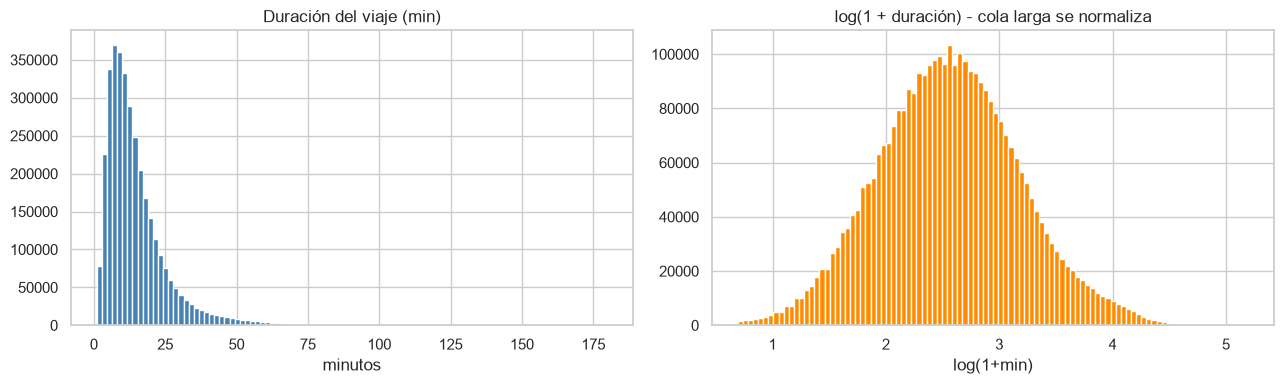

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(d["trip_duration_min"], bins=100, color="steelblue")
axes[0].set_title("Duración del viaje (min)")
axes[0].set_xlabel("minutos")
axes[1].hist(np.log1p(d["trip_duration_min"]), bins=100, color="darkorange")
axes[1].set_title("log(1 + duración) - cola larga se normaliza")
axes[1].set_xlabel("log(1+min)")
plt.tight_layout()
plt.savefig("../reports/figures/01_distribucion_objetivo.png", dpi=150)
plt.show()

La distribución tiene cola larga a la derecha: la mayoría de viajes dura 5–20 min pero existen viajes de horas. Esto motiva la métrica RMSLE como secundaria y sugiere modelar sobre `log(duración)`.

### Visualización 2 — Duración según hora del día

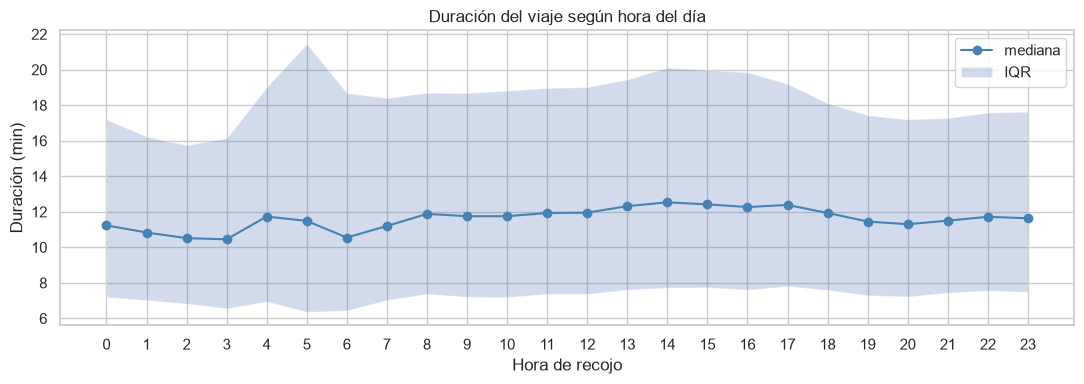

In [13]:
d["hora"] = d["tpep_pickup_datetime"].dt.hour
d["dia_semana"] = d["tpep_pickup_datetime"].dt.dayofweek  # 0 = lunes

plt.figure(figsize=(11, 4))
med = d.groupby("hora")["trip_duration_min"].median()
p25 = d.groupby("hora")["trip_duration_min"].quantile(0.25)
p75 = d.groupby("hora")["trip_duration_min"].quantile(0.75)
plt.plot(med.index, med.values, marker="o", color="steelblue", label="mediana")
plt.fill_between(med.index, p25.values, p75.values, alpha=0.25, label="IQR")
plt.xlabel("Hora de recojo")
plt.ylabel("Duración (min)")
plt.title("Duración del viaje según hora del día")
plt.legend()
plt.xticks(range(24))
plt.tight_layout()
plt.savefig("../reports/figures/02_duracion_por_hora.png", dpi=150)
plt.show()

### Visualización 3 — Demanda por día de la semana y hora (heatmap)

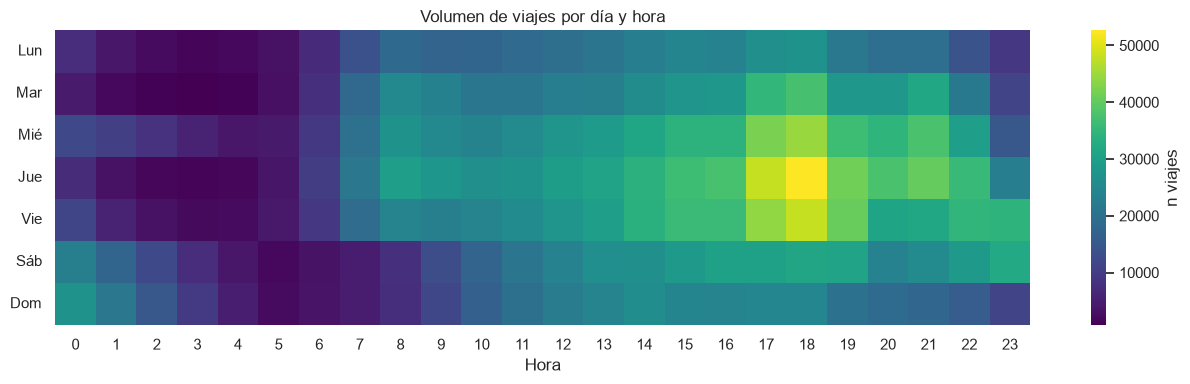

In [14]:
pivote = d.pivot_table(index="dia_semana", columns="hora", values="trip_duration_min", aggfunc="size")
plt.figure(figsize=(13, 4))
sns.heatmap(pivote, cmap="viridis", cbar_kws={"label": "n viajes"})
plt.yticks(ticks=np.arange(7) + 0.5, labels=["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"], rotation=0)
plt.title("Volumen de viajes por día y hora")
plt.xlabel("Hora")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/figures/03_heatmap_demanda.png", dpi=150)
plt.show()

### Visualización 4 — Relación distancia vs. duración

**Nota de leakage:** `trip_distance` **no** estará disponible como feature (se mide al terminar el viaje). La usamos aquí solo para entender la estructura del problema; en el modelo la reemplazará una distancia estimada entre centroides de zonas.

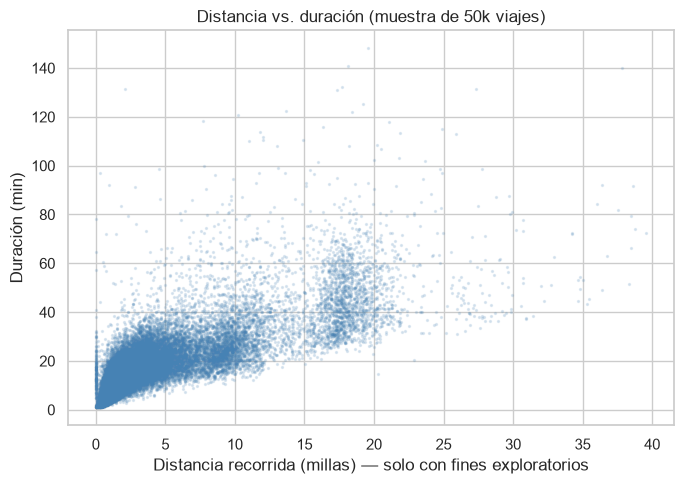

In [15]:
muestra = d[(d["trip_distance"] > 0) & (d["trip_distance"] < 40)].sample(50_000, random_state=SEED)
plt.figure(figsize=(7, 5))
plt.scatter(muestra["trip_distance"], muestra["trip_duration_min"], s=2, alpha=0.15, color="steelblue")
plt.xlabel("Distancia recorrida (millas) — solo con fines exploratorios")
plt.ylabel("Duración (min)")
plt.title("Distancia vs. duración (muestra de 50k viajes)")
plt.tight_layout()
plt.savefig("../reports/figures/04_distancia_vs_duracion.png", dpi=150)
plt.show()

### Visualización 5 — Duración por zona de recojo (top 15 zonas por volumen)

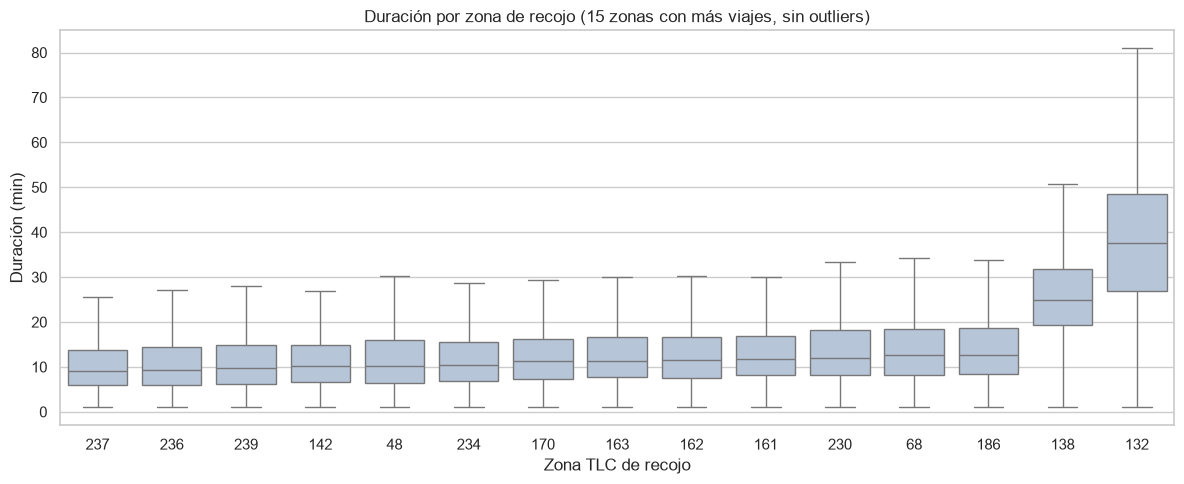

In [16]:
top_zonas = d["PULocationID"].value_counts().head(15).index
sub = d[d["PULocationID"].isin(top_zonas)]
orden = sub.groupby("PULocationID")["trip_duration_min"].median().sort_values().index
plt.figure(figsize=(12, 5))
sns.boxplot(data=sub, x="PULocationID", y="trip_duration_min", order=orden, showfliers=False, color="lightsteelblue")
plt.title("Duración por zona de recojo (15 zonas con más viajes, sin outliers)")
plt.xlabel("Zona TLC de recojo")
plt.ylabel("Duración (min)")
plt.tight_layout()
plt.savefig("../reports/figures/05_duracion_por_zona.png", dpi=150)
plt.show()

### Visualización 6 — Volumen diario del mes (chequeo de integridad temporal)

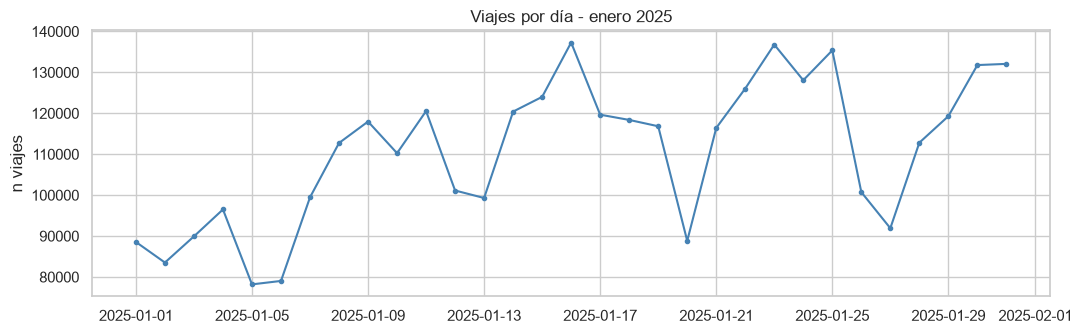

In [18]:
por_dia = d.set_index("tpep_pickup_datetime").resample("D").size()
plt.figure(figsize=(11, 3.5))
plt.plot(por_dia.index, por_dia.values, marker=".", color="steelblue")
plt.title("Viajes por día - enero 2025")
plt.ylabel("n viajes")
plt.tight_layout()
plt.savefig("../reports/figures/06_viajes_por_dia.png", dpi=150)
plt.show()

## 5. Outliers y registros sospechosos

Resumen de lo detectado arriba:

- **Duraciones imposibles**: viajes con duración ≤ 0 o mayores a varias horas (taxímetros mal cerrados).
- **`trip_distance` = 0** con duración positiva: viajes cancelados o error de registro.
- **`passenger_count` = 0 o NaN**: campo ingresado manualmente por el conductor, poco confiable.
- **Zonas 264/265**: códigos de zona desconocida.
- **Fechas fuera del mes del archivo**: registros rezagados de otros meses.
- **Tarifas negativas** (`total_amount` < 0): reembolsos/disputas - irrelevantes para nuestro target pero evidencia de ruido.

Las reglas de exclusión definitivas se implementarán en `src/data.py` con umbrales justificados (p. ej. percentiles) y se reportará qué porcentaje de datos elimina cada regla.

## 6. Sesgos, leakage y limitaciones

**Leakage.** Las columnas `trip_distance`, `fare_amount`, `total_amount`, `tip_amount`, `tolls_amount`, `payment_type`, `tpep_dropoff_datetime`, los recargos (`congestion_surcharge`, `cbd_congestion_fee`, `improvement_surcharge`, `Airport_fee`), `RatecodeID` y `store_and_fwd_flag` se generan durante o al final del viaje. Ejemplo concreto: en la Visualización 4 `trip_distance` explica casi linealmente la duración; un modelo con esa columna daría un MAE excelente pero inútil en producción, porque al recojo nadie conoce la distancia que el taxímetro marcará. Incluir cualquiera como feature produciría métricas irrealmente buenas. El modelo usará únicamente: hora/día del recojo, zonas de recojo y destino, `passenger_count`, `VendorID` y una distancia estimada entre centroides de zonas (construida por nosotros).

**Sesgos.** El dataset cubre solo taxis amarillos, concentrados en Manhattan y aeropuertos; los recojos fuera de Manhattan (Bronx, Staten Island, y gran parte de Brooklyn y Queens) representan una minoria, por lo que el modelo será menos confiable ahí. Además refleja patrones de una sola ciudad y un solo periodo (invierno), lo que limita la generalización estacional — razón por la que la versión final usará 6 meses.

**Limitaciones.** No tenemos tráfico en tiempo real ni clima; parte del error será irreducible con estas features. La zona de destino la asumimos conocida al recojo (el pasajero la declara), supuesto razonable pero que conviene explicitar.

## 7. Primer baseline

Split **temporal** dentro del mes: entrenamos con las 3 primeras semanas y evaluamos en la última. Comparamos: (a) mediana global, (b) mediana por (zona, hora), (c) regresión lineal con features de recojo.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_log_error

corte = pd.Timestamp("2025-01-25")
train = d[d["tpep_pickup_datetime"] < corte]
test = d[d["tpep_pickup_datetime"] >= corte]
y_tr, y_te = train["trip_duration_min"], test["trip_duration_min"]
print(f"Train: {len(train):,} | Test: {len(test):,}")

Train: 2,609,751 | Test: 823,965


In [20]:
def evaluar(nombre, y_real, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    mae = mean_absolute_error(y_real, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_real, y_pred))
    print(f"{nombre:<38} MAE = {mae:6.2f} min | RMSLE = {rmsle:.4f}")
    return {"modelo": nombre, "MAE": mae, "RMSLE": rmsle}

resultados = []

# (a) Mediana global
pred_a = np.full(len(test), y_tr.median())
resultados.append(evaluar("Baseline A: mediana global", y_te, pred_a))

# (b) Mediana por (zona de recojo, hora)
tabla = train.groupby(["PULocationID", "hora"])["trip_duration_min"].median()
pred_b = test.set_index(["PULocationID", "hora"]).index.map(tabla).to_numpy(dtype=float)
pred_b = np.where(np.isnan(pred_b), y_tr.median(), pred_b)
resultados.append(evaluar("Baseline B: mediana por (zona, hora)", y_te, pred_b))

Baseline A: mediana global             MAE =   7.40 min | RMSLE = 0.6184
Baseline B: mediana por (zona, hora)   MAE =   6.38 min | RMSLE = 0.5521


In [21]:
# (c) Regresión lineal — solo features disponibles al recojo
features_cat = ["PULocationID", "DOLocationID", "hora", "dia_semana"]

pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=200), features_cat),
    ])),
    ("modelo", LinearRegression()),
])

pipe.fit(train[features_cat], y_tr)
pred_c = pipe.predict(test[features_cat])
resultados.append(evaluar("Baseline C: regresión lineal", y_te, pred_c))

Baseline C: regresión lineal           MAE =   6.08 min | RMSLE = 0.5343


In [22]:
import json, os
os.makedirs("../outputs", exist_ok=True)
with open("../outputs/metrics_baseline.json", "w") as f:
    json.dump(resultados, f, indent=2)
pd.DataFrame(resultados)

,modelo,MAE,RMSLE
0,Baseline A: mediana global,7.404093,0.618372
1,"Baseline B: mediana por (zona, hora)",6.382967,0.552055
2,Baseline C: regresión lineal,6.078759,0.534317


## 8. Lectura del baseline y siguientes pasos

| Baseline | MAE (min) | RMSLE |
|---|---|---|
| A. Mediana global | 7.40 | 0.618 |
| B. Mediana por (zona de recojo, hora) | 6.38 | 0.552 |
| C. Regresión lineal (zona recojo, zona destino, hora, día) | 6.08 | 0.534 |

**Lectura.** La mediana global fija el piso: sin ningún feature nos equivocamos en promedio por ~7.4 minutos. Condicionar por zona y hora reduce el MAE en ~1 minuto (−14 %), lo que confirma que las variables espaciales y temporales tienen señal real. La regresión lineal, que además incorpora la zona de destino, mejora otros ~0.3 min. La mejora es modesta porque el modelo lineal con one-hot no captura interacciones (p. ej. *origen × destino*, que es lo que define la distancia del viaje) ni la no linealidad de la hora; ese es exactamente el espacio que deben ganar los modelos de árboles.

Los dos datos más importantes que deja la exploración para el modelado:

1. **La distancia es la variable dominante** (Visualización 4), pero `trip_distance` es leakage. Construir una distancia estimada entre centroides de zonas es la prioridad número uno de features.
2. **Las zonas de aeropuerto (132 = JFK, 138 = LaGuardia) tienen medianas de 25–38 min**, muy por encima del resto (Visualización 5). Un indicador de aeropuerto y la distancia estimada deberían capturar gran parte de esa varianza.

Cualquier modelo de las próximas semanas debe superar un MAE de 6.08 min en un split temporal para justificar su complejidad.

**Siguientes pasos:** limpieza definitiva con reglas justificadas en `src/data.py`, feature de distancia estimada entre centroides de zonas (usando `data/Taxi_Zone_Lookup.csv` y el shapefile de zonas TLC), extensión a los 6 meses con split temporal entre meses, y modelos de árboles/gradient boosting.
